# Predicting Abalone Age with Regression
## Kaggle Playground Series S4E4

**Purpose.** This notebook compares an interpretable linear-regression baseline with an XGBoost regressor for predicting `Rings`, an age proxy. Models are evaluated using the competition metric, root mean squared logarithmic error (RMSLE). The workflow includes exploratory analysis, leakage-safe preprocessing, holdout validation, five-fold cross-validation, linear-model diagnostics, model selection, and creation of a Kaggle-ready submission file.

**Reproducibility and security.** The competition data are read directly from Kaggle's mounted input directory. No API token or personal credential is required or stored in this notebook.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load the competition data

Kaggle mounts competition files under `/kaggle/input`. The search below makes the notebook robust to minor differences in the mounted folder name and raises a clear error if the dataset has not been attached.

In [2]:
def locate_file(filename):
    matches = sorted(Path("/kaggle/input").glob(f"**/{filename}"))
    if not matches:
        raise FileNotFoundError(
            f"{filename} was not found. In Kaggle, select Add Input and attach "
            "Playground Series S4E4 before running the notebook."
        )
    return matches[0]

train_path = locate_file("train.csv")
test_path = locate_file("test.csv")
sample_path = locate_file("sample_submission.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print(f"Training data: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Test data:     {test.shape[0]:,} rows x {test.shape[1]} columns")
display(train.head())

Training data: 90,615 rows x 10 columns
Test data:     60,411 rows x 9 columns


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


## 2. Data quality and exploratory analysis

`id` is an identifier and is excluded from modeling. `Sex` is categorical (male, female, or infant); the remaining predictors are physical measurements. The checks below assess data types, missingness, duplicates, target distribution, and bivariate relationships before modeling.

In [3]:
quality_summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "unique": train.nunique(),
})
print(f"Duplicate rows: {train.duplicated().sum():,}")
display(quality_summary)
display(train.describe(include="all").T)

Duplicate rows: 0


,dtype,missing,unique
id,int64,0,90615
Sex,object,0,3
Length,float64,0,157
Diameter,float64,0,126
Height,float64,0,90
Whole weight,float64,0,3175
Whole weight.1,float64,0,1799
Whole weight.2,float64,0,979
Shell weight,float64,0,1129
Rings,int64,0,28


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,90615.0,NaN,NaN,NaN,45307.0,26158.441658,0.0,22653.5,45307.0,67960.5,90614.0
Sex,90615,3,I,33093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Length,90615.0,NaN,NaN,NaN,0.517098,0.118217,0.075,0.445,0.545,0.6,0.815
Diameter,90615.0,NaN,NaN,NaN,0.401679,0.098026,0.055,0.345,0.425,0.47,0.65
Height,90615.0,NaN,NaN,NaN,0.135464,0.038008,0.0,0.11,0.14,0.16,1.13
Whole weight,90615.0,NaN,NaN,NaN,0.789035,0.457671,0.002,0.419,0.7995,1.0675,2.8255
Whole weight.1,90615.0,NaN,NaN,NaN,0.340778,0.204428,0.001,0.1775,0.33,0.463,1.488
Whole weight.2,90615.0,NaN,NaN,NaN,0.169422,0.100909,0.0005,0.0865,0.166,0.2325,0.76
Shell weight,90615.0,NaN,NaN,NaN,0.225898,0.130203,0.0015,0.12,0.225,0.305,1.005
Rings,90615.0,NaN,NaN,NaN,9.696794,3.176221,1.0,8.0,9.0,11.0,29.0


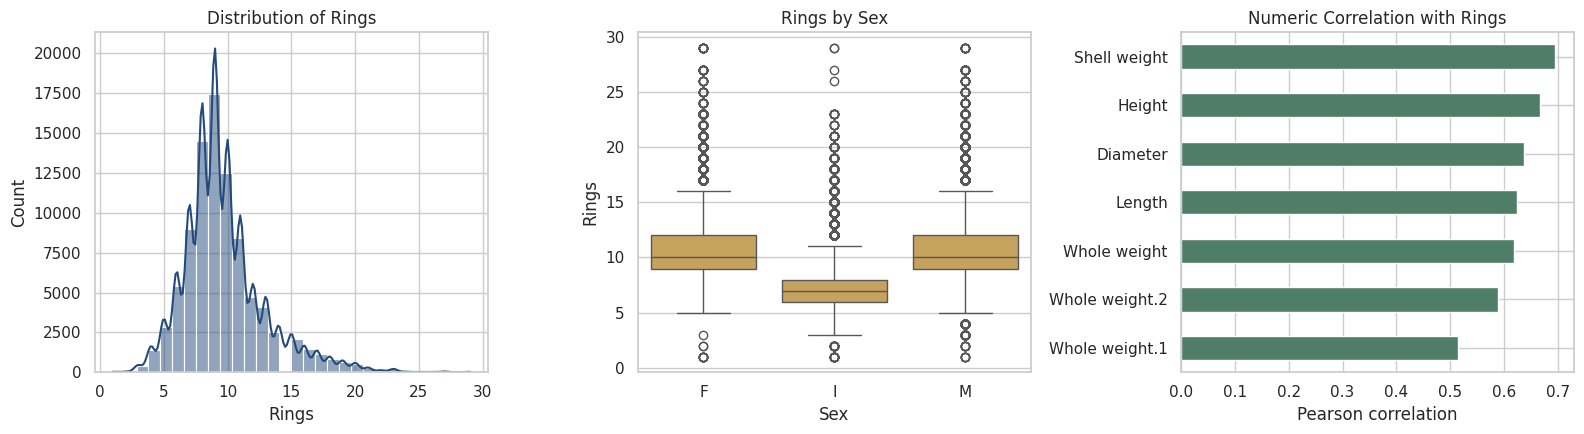

Target summary:


,count,mean,std,min,25%,50%,75%,max
Rings,90615.0,9.696794,3.176221,1.0,8.0,9.0,11.0,29.0


Strongest absolute numeric correlations with Rings:


,absolute_correlation
Shell weight,0.694766
Height,0.665772
Diameter,0.636832
Length,0.623786
Whole weight,0.617274


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(train["Rings"], bins=30, kde=True, ax=axes[0], color="#244a7c")
axes[0].set_title("Distribution of Rings")

sns.boxplot(data=train, x="Sex", y="Rings", ax=axes[1], color="#d7a84b")
axes[1].set_title("Rings by Sex")

corr = train.drop(columns="id").corr(numeric_only=True)["Rings"].drop("Rings").sort_values()
corr.plot(kind="barh", ax=axes[2], color="#4f7d68")
axes[2].set_title("Numeric Correlation with Rings")
axes[2].set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()

print("Target summary:")
display(train["Rings"].describe().to_frame().T)
print("Strongest absolute numeric correlations with Rings:")
display(corr.abs().sort_values(ascending=False).head(5).to_frame("absolute_correlation"))

The target is right-skewed, so large errors on older abalones could dominate an untransformed squared-error objective. The physical measurements are positively related to `Rings`, while the several weight variables are also expected to be strongly correlated with one another. These patterns motivate (1) modeling `log1p(Rings)` to align training with RMSLE and (2) comparing a linear baseline with a nonlinear tree-boosting model capable of learning interactions and curved relationships.

## 3. Preprocessing and validation design

The data are split before fitting transformations. One-hot encoding and scaling are contained inside each pipeline, so they are learned only from the relevant training fold. A fixed 80/20 holdout provides an initial comparison, while shuffled five-fold cross-validation provides the primary model-selection evidence.

In [5]:
target = "Rings"
features = [column for column in train.columns if column not in ("id", target)]
categorical_features = ["Sex"]
numeric_features = [column for column in features if column not in categorical_features]

X = train[features]
y = train[target]
y_log = np.log1p(y)
X_test = test[features]

X_train, X_valid, y_train_log, y_valid_log = train_test_split(
    X, y_log, test_size=0.20, random_state=RANDOM_STATE
)

linear_preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), categorical_features),
    ("numeric", StandardScaler(), numeric_features),
])

tree_preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("numeric", "passthrough", numeric_features),
])

def rmsle_from_log(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.clip(np.expm1(y_pred_log), 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

## 4. Model 1: Linear regression baseline

In [6]:
linear_model = Pipeline([
    ("preprocess", linear_preprocessor),
    ("regressor", LinearRegression()),
])

linear_model.fit(X_train, y_train_log)
linear_valid_pred_log = linear_model.predict(X_valid)
linear_holdout_rmsle = rmsle_from_log(y_valid_log, linear_valid_pred_log)
print(f"Linear regression holdout RMSLE: {linear_holdout_rmsle:.5f}")

Linear regression holdout RMSLE: 0.16662


## 5. Model 2: XGBoost regression

In [7]:
xgb_model = Pipeline([
    ("preprocess", tree_preprocessor),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=600,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb_model.fit(X_train, y_train_log)
xgb_valid_pred_log = xgb_model.predict(X_valid)
xgb_holdout_rmsle = rmsle_from_log(y_valid_log, xgb_valid_pred_log)
print(f"XGBoost holdout RMSLE: {xgb_holdout_rmsle:.5f}")

XGBoost holdout RMSLE: 0.15141


## 6. Five-fold cross-validation and model comparison

RMSLE is calculated on predictions returned to the original `Rings` scale. Lower values indicate better performance. Using identical folds for both models makes the comparison direct and reproducible.

In [8]:
def cross_validated_rmsle(model, X_data, y_log_data, folds):
    scores = []
    for fold, (train_index, valid_index) in enumerate(folds.split(X_data), start=1):
        X_fold_train = X_data.iloc[train_index]
        X_fold_valid = X_data.iloc[valid_index]
        y_fold_train = y_log_data.iloc[train_index]
        y_fold_valid = y_log_data.iloc[valid_index]

        model.fit(X_fold_train, y_fold_train)
        prediction_log = model.predict(X_fold_valid)
        score = rmsle_from_log(y_fold_valid, prediction_log)
        scores.append(score)
        print(f"Fold {fold}: {score:.5f}")
    return np.array(scores)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Linear regression")
linear_cv_scores = cross_validated_rmsle(linear_model, X, y_log, kfold)
print("\nXGBoost")
xgb_cv_scores = cross_validated_rmsle(xgb_model, X, y_log, kfold)

Linear regression
Fold 1: 0.16662
Fold 2: 0.16546
Fold 3: 0.16514
Fold 4: 0.16375
Fold 5: 0.16150

XGBoost
Fold 1: 0.15153
Fold 2: 0.15057
Fold 3: 0.14945
Fold 4: 0.14908
Fold 5: 0.14679


In [9]:
results = pd.DataFrame({
    "Model": ["Linear regression", "XGBoost"],
    "Holdout RMSLE": [linear_holdout_rmsle, xgb_holdout_rmsle],
    "Mean CV RMSLE": [linear_cv_scores.mean(), xgb_cv_scores.mean()],
    "CV standard deviation": [linear_cv_scores.std(ddof=1), xgb_cv_scores.std(ddof=1)],
}).sort_values("Mean CV RMSLE").reset_index(drop=True)

linear_mean = linear_cv_scores.mean()
xgb_mean = xgb_cv_scores.mean()
improvement = 100 * (linear_mean - xgb_mean) / linear_mean

display(results.style.format({
    "Holdout RMSLE": "{:.5f}",
    "Mean CV RMSLE": "{:.5f}",
    "CV standard deviation": "{:.5f}",
}))
print(f"XGBoost CV improvement over linear regression: {improvement:.2f}%")

,Model,Holdout RMSLE,Mean CV RMSLE,CV standard deviation
0,XGBoost,0.15141,0.14948,0.00179
1,Linear regression,0.16662,0.16450,0.00196


XGBoost CV improvement over linear regression: 9.13%


### Model-comparison interpretation

XGBoost yielded a lower mean five-fold cross-validation RMSLE of 0.14948, compared to 0.16449 for linear regression. XGBoost reduced mean cross-validation RMSLE by approximately: $(0.16449−0.14948)/0.16449 x 100 = 9.13% $

This result corresponds to an approximate 9.13% reduction in prediction error. XGBoost also demonstrated a marginally lower cross-validation standard deviation and consistently outperformed linear regression across all folds. Consequently, XGBoost was selected as the final model due to its superior ability to capture nonlinear relationships and interactions among sex, physical dimensions, and weight measurements.

## 7. Linear-regression assumptions and diagnostics

Classical regression diagnostics apply to the linear baseline, not to XGBoost in the same way. Residual-versus-fitted and Q-Q plots assess linearity, variance behavior, and residual normality. The Breusch–Pagan test formally evaluates constant variance. Variance inflation factors (VIFs) assess multicollinearity, while studentized residuals, leverage, and Cook's distance identify unusual or influential observations. Because the competition observations are separately recorded abalones and no time ordering is specified, independence is primarily justified by the data-collection structure rather than a time-series statistic.

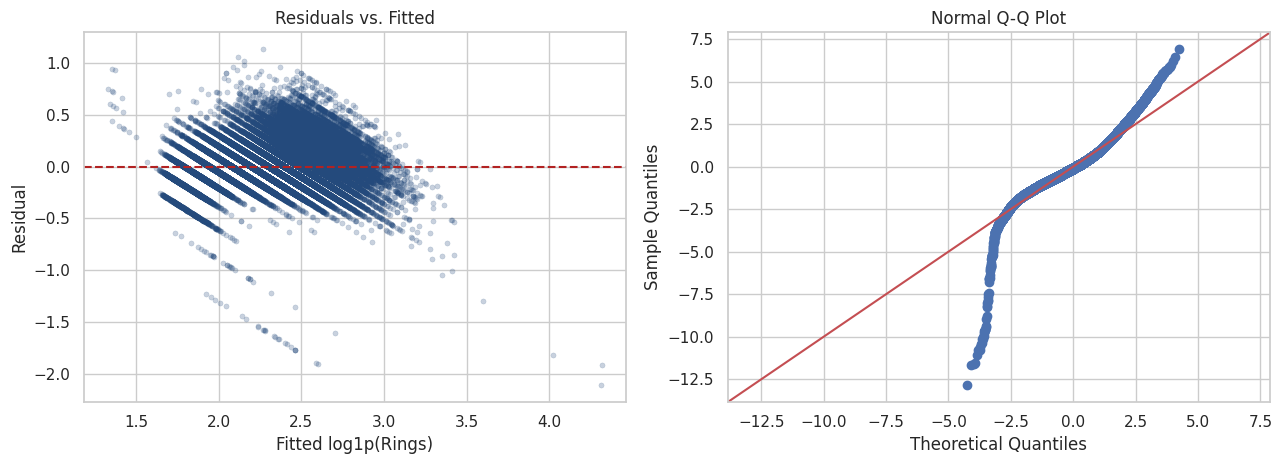

Breusch-Pagan LM statistic: 4311.780
Breusch-Pagan p-value:      0


In [10]:
# Refit the baseline on all training observations for diagnostics.
linear_model.fit(X, y_log)
X_linear = linear_model.named_steps["preprocess"].transform(X)
feature_names = linear_model.named_steps["preprocess"].get_feature_names_out()
X_diagnostic = sm.add_constant(X_linear, has_constant="add")
ols_result = sm.OLS(y_log.to_numpy(), X_diagnostic).fit()

fitted = ols_result.fittedvalues
residuals = ols_result.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.scatterplot(x=fitted, y=residuals, s=14, alpha=0.25, ax=axes[0], color="#244a7c", edgecolor=None)
axes[0].axhline(0, color="firebrick", linestyle="--")
axes[0].set(title="Residuals vs. Fitted", xlabel="Fitted log1p(Rings)", ylabel="Residual")

sm.qqplot(residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Normal Q-Q Plot")
plt.tight_layout()
plt.show()

bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(residuals, X_diagnostic)
print(f"Breusch-Pagan LM statistic: {bp_stat:.3f}")
print(f"Breusch-Pagan p-value:      {bp_pvalue:.6g}")

In [11]:
# -----------------------------
# Efficient VIF analysis
# -----------------------------
DIAGNOSTIC_SAMPLE_SIZE = min(50_000, len(train))

diagnostic_index = train.sample(
    n=DIAGNOSTIC_SAMPLE_SIZE,
    random_state=42
).index

vif_data = train.loc[
    diagnostic_index,
    numeric_features
].astype(float)

# Standardize for numerical stability
vif_standardized = (
    (vif_data - vif_data.mean())
    / vif_data.std(ddof=0).replace(0, 1)
)

numeric_for_vif = sm.add_constant(
    vif_standardized,
    has_constant="add"
)

vif_values = numeric_for_vif.to_numpy()

# Exclude the constant from both lists
predictor_names = numeric_for_vif.columns[1:]

vif_scores = [
    variance_inflation_factor(vif_values, i)
    for i in range(1, vif_values.shape[1])
]

vif_table = pd.DataFrame({
    "Predictor": predictor_names,
    "VIF": vif_scores
})

display(
    vif_table
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

,Predictor,VIF
0,Whole weight,68.842027
1,Diameter,53.641465
2,Length,51.048527
3,Whole weight.1,21.542981
4,Whole weight.2,20.110846
5,Shell weight,18.416105
6,Height,8.148841


Because the Kaggle training dataset contains a very large number of observations, VIF and influence diagnostics were performed on a reproducible random sample of 50,000 records. This sample is sufficiently large for identifying broad multicollinearity, residual, leverage, and influence patterns while avoiding the excessive computational cost of leave-one-out diagnostics on the complete dataset. Internal studentized residuals were used because externally studentized residuals would require substantially more computation.

In [12]:
# Efficient influence diagnostics using the existing 50,000-row sample
X_influence = X_diagnostic[diagnostic_index]
y_influence = y_log.loc[diagnostic_index].to_numpy()

diagnostic_result = sm.OLS(
    y_influence,
    X_influence
).fit()

influence = diagnostic_result.get_influence()

influence_table = pd.DataFrame({
    "studentized_residual": influence.resid_studentized_internal,
    "leverage": influence.hat_matrix_diag,
    "cooks_distance": influence.cooks_distance[0],
}, index=diagnostic_index)

n_diag = X_influence.shape[0]
p_diag = X_influence.shape[1]

flagged = influence_table[
    (influence_table["studentized_residual"].abs() > 3)
    | (influence_table["leverage"] > 2 * p_diag / n_diag)
    | (influence_table["cooks_distance"] > 4 / n_diag)
].copy()

print(f"Diagnostic sample size: {n_diag:,}")
print(
    f"Flagged observations: {len(flagged):,} of {n_diag:,} "
    f"({100 * len(flagged) / n_diag:.2f}%)"
)

display(
    flagged.sort_values(
        "cooks_distance",
        ascending=False
    ).head(10)
)

Diagnostic sample size: 50,000
Flagged observations: 5,469 of 50,000 (10.94%)


,studentized_residual,leverage,cooks_distance
16384,-14.516641,0.115293,2.746221
58048,-4.696213,0.012231,0.027310
3077,4.412554,0.006355,0.012453
56089,-3.015425,0.011983,0.011028
52990,-6.339587,0.002095,0.008438
72349,5.610384,0.002310,0.007288
27392,-5.226391,0.002461,0.006740
5365,4.869879,0.002816,0.006697
66689,4.409204,0.002979,0.005808
41324,3.361814,0.004968,0.005643


The residual-versus-fitted plot displays structured residual behavior and unequal variance, suggesting that the linear model does not fully represent the relationship between the predictors and log-transformed Rings. The Q-Q plot shows substantial departures from normality in both tails. Furthermore, the Breusch–Pagan test was statistically significant, LM = 4,311.78, p < .001, providing evidence of heteroscedasticity. VIF values were especially high for Whole weight, Diameter, and Length, indicating severe multicollinearity among the physical measurements. These limitations affect interpretation of the linear model and support the use of XGBoost, which achieved substantially better out-of-sample predictive performance.

### Diagnostic interpretation

Within the diagnostic sample of 50,000 observations, 5,469 cases (10.94%) were identified by at least one criterion: studentized residual, leverage, or Cook’s distance. Observation 16,384 demonstrated particular influence, exhibiting a studentized residual of −14.52, leverage of 0.1153, and Cook’s distance of 2.746. These results indicate that certain atypical observations impact the linear model fit. Nevertheless, flagged cases warrant further investigation rather than automatic exclusion.

## 8. Refit the best model and create `submission.csv`

In [13]:
model_lookup = {
    "Linear regression": linear_model,
    "XGBoost": xgb_model,
}
best_model_name = results.loc[0, "Model"]
best_model = model_lookup[best_model_name]
best_model.fit(X, y_log)

test_prediction_log = best_model.predict(X_test)
test_prediction = np.clip(np.expm1(test_prediction_log), 0, None)

submission = sample_submission.copy()
submission[target] = test_prediction
submission_path = Path("/kaggle/working/submission.csv")
submission.to_csv(submission_path, index=False)

# Submission integrity checks
assert list(submission.columns) == list(sample_submission.columns)
assert len(submission) == len(test)
assert submission["id"].equals(test["id"])
assert submission[target].notna().all()
assert np.isfinite(submission[target]).all()
assert (submission[target] >= 0).all()

print(f"Selected model: {best_model_name}")
print(f"Saved: {submission_path}")
print(f"Submission shape: {submission.shape}")
display(submission.head())

Selected model: XGBoost
Saved: /kaggle/working/submission.csv
Submission shape: (60411, 2)


,id,Rings
0,90615,9.740460
1,90616,9.637575
2,90617,10.089111
3,90618,10.141522
4,90619,7.519699


## 9. Conclusion

XGBoost was selected as the final model because it achieved a mean five-fold CV RMSLE of 0.14948, compared with 0.16449 for linear regression—a 9.13% improvement. After refitting XGBoost on all 90,615 training observations, the model generated 60,411 valid, nonnegative predictions in the required submission format.

This analysis uses a reproducible, leakage-safe workflow to compare linear regression and XGBoost with both holdout validation and five-fold cross-validation. The final model is selected objectively using the lower mean CV RMSLE and is then refitted on all labeled observations. The diagnostic analysis clarifies why the linear model is valuable as a transparent benchmark but may not fully represent nonlinear relationships, unequal variance, multicollinearity, and influential cases in the data. The integrity checks confirm that `/kaggle/working/submission.csv` has the required columns, row count, identifiers, and valid nonnegative predictions and is ready for submission through Kaggle's **Submit to Competition** interface.